In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
caminho='/content/Social_Network_Ads.csv'
df=pd.read_csv(caminho)
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [ ]:
# Renomeando as colunas
df=df.rename(columns={'Age':'Idade','EstimatedSalary':'Salário Estimado','Purchased':'Compra'})
df.head()

,Idade,Salário Estimado,Compra
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [ ]:
df.describe(include='number').T

,Idade,Salário Estimado,Compra
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [ ]:
#Dados faltantes
df.isna().sum()

,0
Idade,0
Salário Estimado,0
Compra,0


In [ ]:
alvo='Compra'
df[alvo].value_counts().sort_index()

,count
Compra,
0,257
1,143


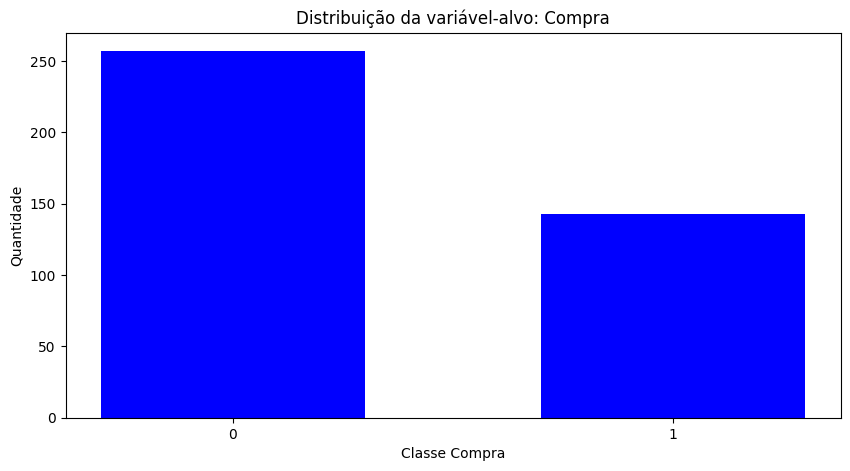

In [ ]:

classe_counts =df[alvo].value_counts().sort_index()

labels = classe_counts.index
quantidades = classe_counts.values

# Gerar posições: 0, 1, 2, 3...
posicoes = np.arange(len(labels))

# Criar o gráfico
plt.figure(figsize=(10, 5))
plt.bar(posicoes, quantidades, width=0.6, color='blue') # width=0.6 para barras mais largas

# Configurar os rótulos do eixo X
plt.xticks(posicoes, labels)

# Adicionar títulos e rótulos
plt.title('Distribuição da variável-alvo: Compra')
plt.xlabel('Classe Compra')
plt.ylabel('Quantidade')

plt.show()

In [ ]:
x=df.drop(alvo,axis=1)
x

,Idade,Salário Estimado
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [ ]:
x_numericas=x.select_dtypes(include='number').columns.tolist()
x_numericas

['Idade', 'Salário Estimado']

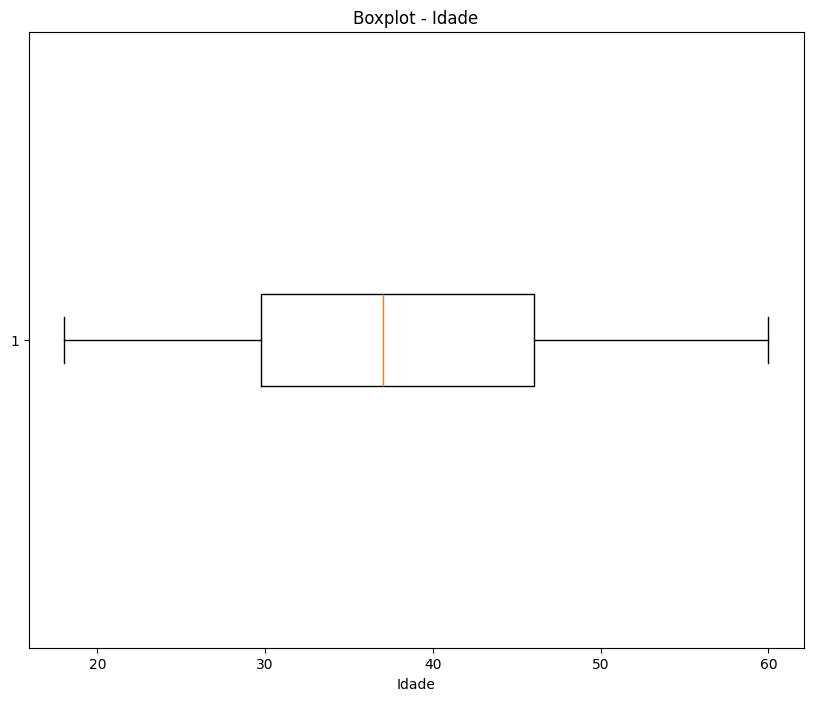

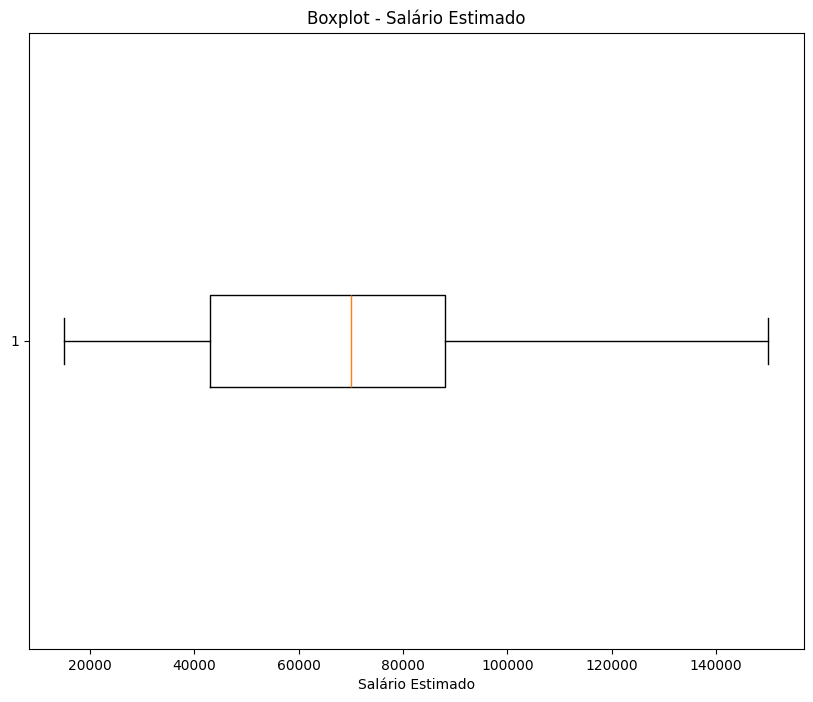

In [ ]:

for col in x_numericas:
    plt.figure(figsize=(10,8))
    plt.boxplot(df[col],vert=False)
    plt.title(f'Boxplot - {col}')
    plt.xlabel(col)
    plt.show()

In [ ]:
!pip install -q groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 4.4 MB/s eta 0:00:00


In [ ]:
from groq import Groq
from google.colab import files
import base64

from google.colab import userdata
groq_api_key= userdata.get('api')

client = Groq(api_key=groq_api_key)

def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(
            image_file.read()
        ).decode("utf-8")

In [ ]:
arquivo = files.upload()
nome_arquivo = list(arquivo.keys())[0]
print("Arquivo selecionado:", nome_arquivo)
base64_image = encode_image(nome_arquivo)

In [ ]:
prompt= input("Digite aqui sua pergunta===>")
display(prompt)

In [ ]:
response = client.chat.completions.create(
    model="qwen/qwen3.8-27b",
    max_tokens=800,  # deve ser <= 1000 (limite de OTPM)
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": prompt
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/png;base64,{base64_image}"
                    }
                }
            ]
        }
    ],
    temperature=0,
)

print(response.choices[0].message.content)